# FreezeNet wheat freeze-injury phenotyping — minimal reproduction

**Paper:** *FreezeNet: A Lightweight Model for Enhancing Freeze Tolerance Assessment and Genetic Analysis in Wheat*, Plant Phenomics 2025;7(2):100061 (PMC12710041, DOI 10.1016/j.plaphe.2025.100061).
**Author code:** https://github.com/Jiang-Phenomics-Lab/FreezeNet pinned at commit `25b66f0b9269bc83a5c95daba153b03b78e6b132`.

**Scope (partial demonstration):** the paper's image phenotyping path on the 6 author-provided sample field images — ring ROI detection (Hough circles), 512x512 crop, FreezeNet plant segmentation with the pretrained checkpoint, and HSV-based trait extraction (GreenLeafRation, YellowLeafRation = YVF, GreenLeaf/YellowLeaf/TotalLeaf areas, mean Hue/Sat), compared against the **author's own embedded reference outputs** from `phenotyping.ipynb`.

**Out of scope:** model training, the Table-1 segmentation benchmark, GWAS/QTL analysis and the breeding-layer analyses.

**Provenance:** all scientific code cells below are verbatim copies (or minimal labeled glue) of the author's pinned Python; the authors wrote this pipeline in Python, so there is **no AI translation of author code**. Glue (download/verification cells, plotting) is AI-authored and labeled.

**実行内容(日本語):** 論文の画像フェノタイピング処理(リングROI検出 → 512x512クロップ → FreezeNetによる植物セグメンテーション → HSV形質抽出)を、著者提供のサンプル画像6枚で再現し、著者ノートブックの参照出力と照合します。学習・ベンチマーク・GWASは対象外です。

## Runtime selection

**Select Runtime > Change runtime type > CPU (recommended).** FreezeNet has only ~1.02M parameters and processes one 512x512 image at a time, so CPU inference takes seconds; the scientific result is identical on GPU. The notebook keeps the author's own device detection (`cuda` if available, else `cpu`) and runs unmodified on a T4 GPU.

**Run all:** Runtime > Run all. Expected on free-tier CPU: ~1-2 min total (about 45 MB downloads + setup + 6 inferences). No Google Drive, no login, no credentials.

**ランタイム(日本語):** 「CPU」を推奨します。モデルは約102万パラメータと小型で、CPUでも数秒/枚です。GPU(T4)でもそのまま動作します。すべてのセルを上から順に実行してください(合計約1〜2分、ダウンロード約45MB)。

In [ ]:
import sys, pathlib, hashlib
import numpy as np
import cv2
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
import requests

print("Python", sys.version.split()[0], "| torch", torch.__version__,
      "| cv2", cv2.__version__, "| numpy", np.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Selected device:", DEVICE, "(author code: 'cuda' if available else 'cpu')")

Python 3.13.16 | torch 2.11.0+cpu | cv2 5.0.0 | numpy 2.1.3
CUDA available: False
Selected device: cpu (author code: 'cuda' if available else 'cpu')


## 1. Fetch the pinned author code

We download the two author source files needed for the minimal path — `nets/FreezeNet.py` (model definition) and `utils/util.py` (`find_ring`) — from the pinned commit `25b66f0b9269bc83a5c95daba153b03b78e6b132`. Each file is verified against its expected byte size **and git blob SHA-1**, so a changed or truncated download fails loudly. (AI-authored glue cell; author code is imported unmodified.)

**日本語:** 著者リポジトリの固定コミットからモデル定義と `find_ring` を取得し、サイズと git blob SHA-1 で完全性を検証します。

In [ ]:
COMMIT = "25b66f0b9269bc83a5c95daba153b03b78e6b132"
BASE = f"https://raw.githubusercontent.com/Jiang-Phenomics-Lab/FreezeNet/{COMMIT}"
CODE_FILES = {
    "nets/FreezeNet.py": (9014, "ec7257a42a8ae1929586c4b5b4f905ba577a4bf2"),
    "utils/util.py":     (5645, "06e9a079f1fdff3cce1bc1d9a384521ddb0a3da9"),
}
ROOT = pathlib.Path("/content/freeze_net")

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

for rel, (size, sha) in CODE_FILES.items():
    dest = ROOT / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    r = requests.get(f"{BASE}/{rel}", timeout=60)
    r.raise_for_status()
    assert len(r.content) == size, f"{rel}: expected {size} bytes, got {len(r.content)}"
    assert git_blob_sha(r.content) == sha, f"{rel}: blob SHA mismatch"
    dest.write_bytes(r.content)
    print(f"verified {rel}: {len(r.content)} bytes, blob {sha[:12]}…")

sys.path.insert(0, str(ROOT))

verified nets/FreezeNet.py: 9014 bytes, blob ec7257a42a8a…
verified utils/util.py: 5645 bytes, blob 06e9a079f1fd…


## 2. Fetch the author-provided sample images

The repository `datasets/` folder contains six real field photos taken on 2023-02-18 (the paper's scoring date), named `<plot>_<date>_<time>.jpg`. We use **all six** because the author's `phenotyping.ipynb` embedded reference output is a 6-row table over exactly these samples — the smallest set that validates the pipeline. Sizes and git blob SHAs are verified after download. (AI-authored glue cell.)

**日本語:** 著者の `datasets/` にある2023-02-18撮影の実フィールド画像6枚を取得します。著者ノートブックの参照出力がこの6枚の表であるため、検証には6枚すべてが必要です。

In [ ]:
SAMPLES = {
    "2022C016_20230218_102707.jpg": (5509835, "74693a49d4cc0b4d05cc1280135f1a83e9dcc1e2"),
    "2022C035_20230218_102926.jpg": (5786872, "ce1d0558635a6817ba2823c231b882effb22afcf"),
    "2022C071_20230218_103407.jpg": (6180727, "ed7e0d3abff2c9a8696b7d0e795b530e1f228446"),
    "2022C094_20230218_103739.jpg": (5420251, "635dcf4947dbb7cfea1997a8b52b8dd832b737aa"),
    "2022C121_20230218_104116.jpg": (6038895, "323e52a2774c5ca3b6f1862063d140565b4a87fb"),
    "2022C147_20230218_104450.jpg": (5497886, "9dbc17510364140a67093028df5f9a2738038a3d"),
}
DATA_DIR = ROOT / "datasets"
DATA_DIR.mkdir(parents=True, exist_ok=True)
for name, (size, sha) in SAMPLES.items():
    dest = DATA_DIR / name
    if not dest.exists():
        r = requests.get(f"{BASE}/datasets/{name}", timeout=300)
        r.raise_for_status()
        assert len(r.content) == size and git_blob_sha(r.content) == sha, name
        dest.write_bytes(r.content)
    img = cv2.imread(str(dest))
    assert img is not None and img.shape[:2] == (4032, 3024), (name, img.shape if img is not None else None)
    print(f"verified {name}: {size} bytes, image {img.shape[1]}x{img.shape[0]}")

verified 2022C016_20230218_102707.jpg: 5509835 bytes, image 3024x4032


verified 2022C035_20230218_102926.jpg: 5786872 bytes, image 3024x4032


verified 2022C071_20230218_103407.jpg: 6180727 bytes, image 3024x4032


verified 2022C094_20230218_103739.jpg: 5420251 bytes, image 3024x4032


verified 2022C121_20230218_104116.jpg: 6038895 bytes, image 3024x4032


verified 2022C147_20230218_104450.jpg: 5497886 bytes, image 3024x4032


## 3. Acquire the pretrained checkpoint (`phoneLite.pth`)

Two author routes exist:

- **Route A (author-designated):** the TeraBox share `https://1024terabox.com/s/1TIZ8BPf0AlSY-yIJSIpUzQ` (from the README "Checkpoint" section). TeraBox download links normally require a logged-in cookie; we make one bounded credential-free probe of its public share API and use it only if it yields a direct link.
- **Route B (pinned git history):** `model/phoneLite.pth` was committed as a real blob (4,426,309 bytes, git blob `f11c8c3af851dff2741155a84c2ea1f26384ccbb`) at commit `ccb27fecac629ea775a1d28b33821d2d35d088ab` (2024-12-18) and later removed. It remains publicly downloadable at that exact revision — a pinned author asset, verified here by size and blob SHA after download.

Whichever route succeeds, scientific validity is decided by the strict `state_dict` load and the reference-table comparison below, not by the route. (AI-authored glue cell.)

**日本語:** チェックポイントはTeraBox共有(著者指定)から取得を試み、ダメな場合は著者リポジトリの過去コミットに存在した `model/phoneLite.pth` をピン留めしたリビジョンから取得します。どちらもサイズ/SHAで検証し、最終的な妥当性は後の参照表との照合で判断します。

In [ ]:
CHECKPOINT = ROOT / "model" / "phoneLite.pth"
TERABOX_SHARE = "https://1024terabox.com/s/1TIZ8BPf0AlSY-yIJSIpUzQ"
PAST_COMMIT = "ccb27fecac629ea775a1d28b33821d2d35d088ab"
PAST_BLOB_SHA = "f11c8c3af851dff2741155a84c2ea1f26384ccbb"

def terabox_direct_link(share_url):
    short = share_url.rstrip("/").split("/")[-1]
    for api in ("https://www.terabox.app/api/share/list",
                "https://www.terabox.com/api/share/list"):
        try:
            r = requests.get(api, params={"app_id": "250528", "shorturl": short, "root": "1"},
                             timeout=30)
        except requests.RequestException as e:
            print("probe failed:", api, type(e).__name__)
            continue
        if r.status_code != 200:
            print(f"{api} -> HTTP {r.status_code}")
            continue
        try:
            info = r.json()
        except ValueError:
            print(f"{api} -> non-JSON response")
            continue
        entries = info.get("list") or []
        if entries and entries[0].get("dlink"):
            return entries[0]["dlink"]
        print(f"{api} -> share reachable, no credential-free dlink (errno={info.get('errno')})")
    return None

route = None
if not CHECKPOINT.exists():
    dl = terabox_direct_link(TERABOX_SHARE)
    if dl:
        try:
            r = requests.get(dl, timeout=600)
            if r.status_code == 200 and len(r.content) > 1_000_000:
                CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
                CHECKPOINT.write_bytes(r.content)
                route = "TeraBox share (author-designated)"
                print(f"TeraBox download OK: {len(r.content)} bytes")
            else:
                print(f"TeraBox dlink unusable: HTTP {r.status_code}, {len(r.content)} bytes")
        except requests.RequestException as e:
            print("TeraBox download failed:", type(e).__name__)
if not CHECKPOINT.exists():
    url = f"https://raw.githubusercontent.com/Jiang-Phenomics-Lab/FreezeNet/{PAST_COMMIT}/model/phoneLite.pth"
    r = requests.get(url, timeout=600)
    r.raise_for_status()
    assert len(r.content) == 4426309, f"unexpected size {len(r.content)}"
    assert git_blob_sha(r.content) == PAST_BLOB_SHA, "blob SHA mismatch"
    CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
    CHECKPOINT.write_bytes(r.content)
    route = f"pinned git-history blob @ {PAST_COMMIT[:8]}"
    print(f"git-history download OK: {len(r.content)} bytes, blob {PAST_BLOB_SHA[:12]}…")
print("Checkpoint route:", route)

https://www.terabox.app/api/share/list -> non-JSON response


https://www.terabox.com/api/share/list -> non-JSON response


git-history download OK: 4426309 bytes, blob f11c8c3af851…
Checkpoint route: pinned git-history blob @ ccb27fec


## 4. Input preview

Before any inference, here are the six ring-cropped inputs exactly as the pipeline sees them (author preprocessing, defined in the next cell). These are the real samples: field photos of plots `2022C016, C035, C071, C094, C121, C147` photographed on 2023-02-18 inside the 34.5 cm ring.

**日本語:** 推論前に、パイプラインが実際に入力する6枚のリングクロップ画像を表示します(2023-02-18撮影の実サンプル、前処理は著者コードそのまま)。

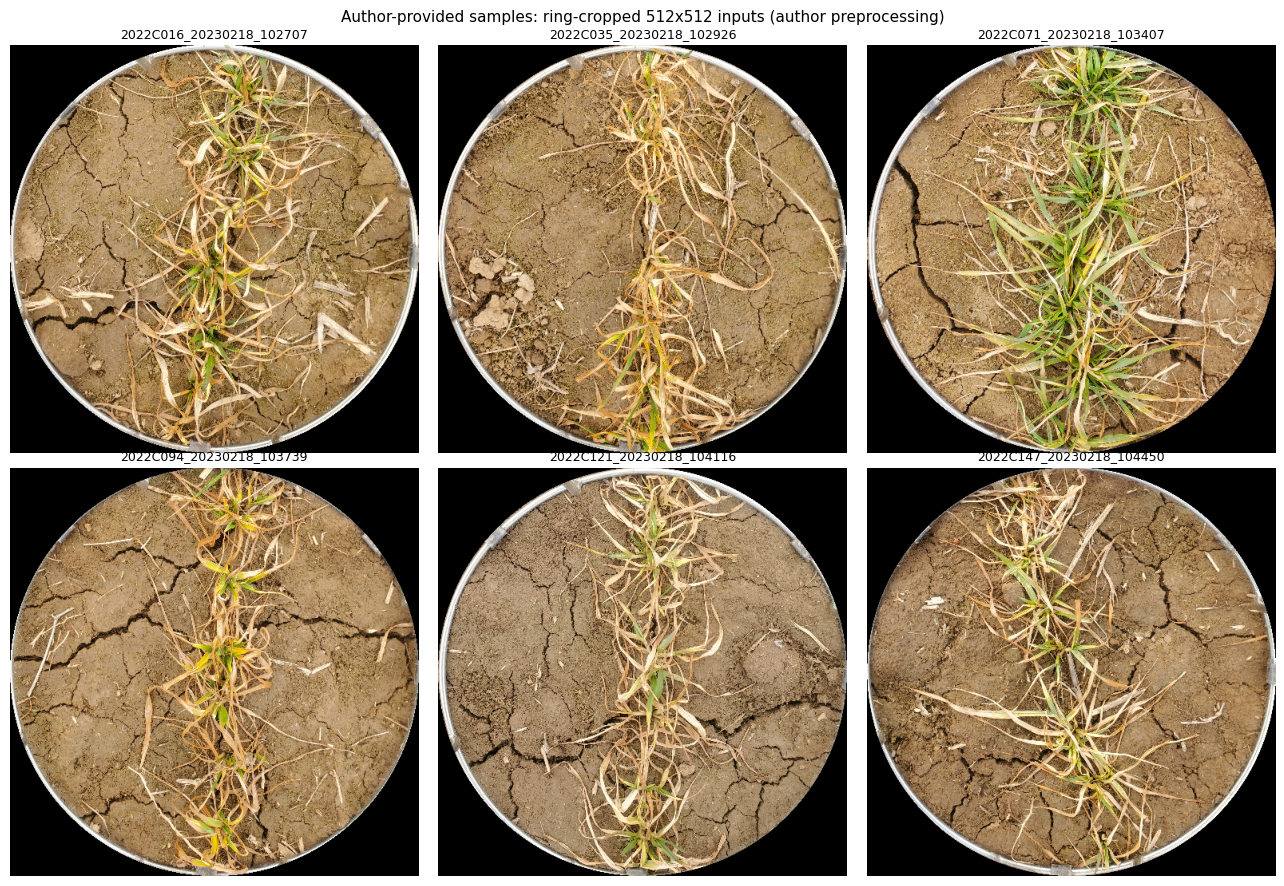

In [ ]:
from utils.util import find_ring  # author code, pinned commit

def preprocess_field_image(path, input_shape=512):
    """Verbatim reproduction of the author's preprocessing (phenotyping.ipynb cell 3 / predict.py):
    rotate if wider than tall, scale ratio 512/w, Hough ring detection, mask outside the ring,
    crop to the ring bounding box, resize to 512x512."""
    image = cv2.imread(str(path))
    h, w = image.shape[:2]
    if h < w:
        image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
        h, w = w, h
    ratio = input_shape / w
    x1, x2, y1, y2, circles = find_ring(image.copy(), ratio)
    ring = np.zeros((int(h), int(w), 3), dtype=np.uint8)
    cv2.circle(ring, (round(circles[0][0][0] / ratio), round(circles[0][0][1] / ratio)),
               round(circles[0][0][2] / ratio), (255, 255, 255), -1)
    image = cv2.bitwise_and(image, ring)
    image = image[y1:y2, x1:x2, :]
    image = cv2.resize(image, (input_shape, input_shape))
    return image

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, name in zip(axes.ravel(), sorted(SAMPLES)):
    crop = preprocess_field_image(DATA_DIR / name)
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_title(name.rsplit(".", 1)[0], fontsize=9)
    ax.axis("off")
fig.suptitle("Author-provided samples: ring-cropped 512x512 inputs (author preprocessing)", fontsize=11)
fig.tight_layout()
plt.show()

## 5. Load FreezeNet with the pretrained checkpoint

We instantiate the author's `FreezeNet` (MobileNetV2-style inverted-residual backbone + bidirectional cross-attention blocks, 2-class output, verbatim from the pinned commit), print its parameter count for comparison with the paper's 1.02 M, and load the checkpoint with **strict** key matching — a wrong or corrupt checkpoint fails here. `nn.DataParallel` is kept exactly as the author wrote it (it is a pass-through on CPU).

**日本語:** 著者の `FreezeNet` を固定コミットからそのまま構築し、パラメータ数(論文は約102万)を確認してから、チェックポイントを strict モードで読み込みます。失敗すればここで明示的にエラーになります。

In [ ]:
from nets.FreezeNet import FreezeNet

model = FreezeNet()
n_params = sum(p.numel() for p in model.parameters())
print(f"FreezeNet parameters: {n_params/1e6:.2f} M (paper Section 3.2: 1.02 M)")
state = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(state)  # strict=True: keys must match exactly
model = nn.DataParallel(model)  # author line; pass-through on CPU
model = model.to(DEVICE)
model = model.eval()
print("Checkpoint loaded strictly into FreezeNet on", DEVICE)

FreezeNet parameters: 1.02 M (paper Section 3.2: 1.02 M)
Checkpoint loaded strictly into FreezeNet on cpu


## 6. Inference on the six samples — input vs. predicted mask

For each sample we run the author's exact inference recipe (pixels/255, BGR, `torch.from_numpy(...).float()`, no other normalization), take `argmax` over the 2-class output as the plant mask, and show **input (top) vs. FreezeNet prediction overlay (bottom)**: predicted plant pixels keep their original colors, background is dimmed. This figure is the notebook's own generated evidence; there are no published reference masks to compare against.

**日本語:** 著者と同じ前処理・推論(255で正規化するだけ)で6枚を処理し、argmaxで植物マスクを得ます。上段が入力、下段が予測マスクのオーバーレイです。

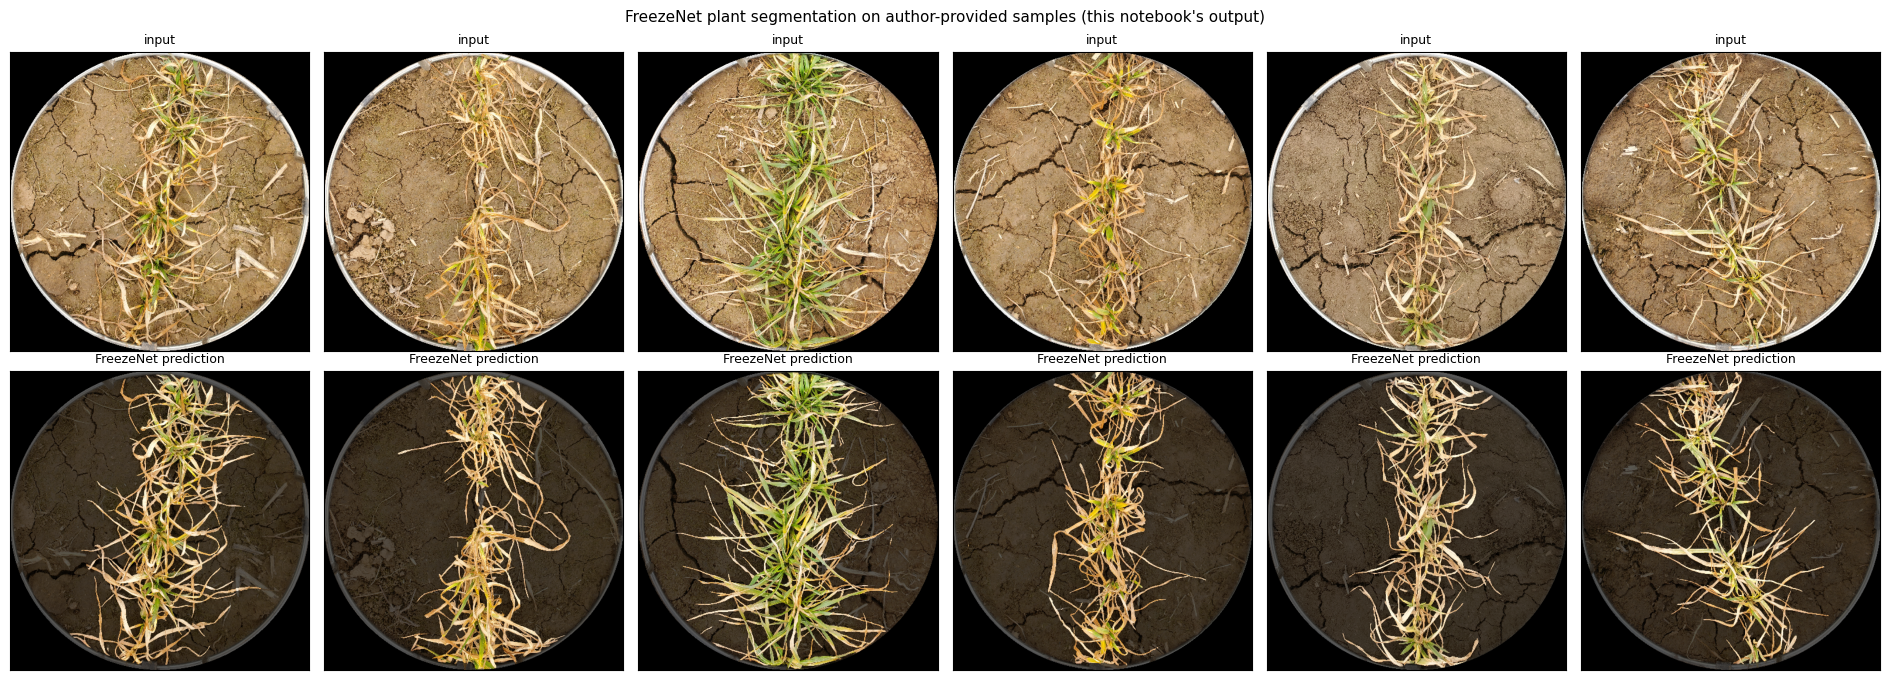

Plant pixels per 512x512 mask: {'2022C016_20230218_102707': 44570, '2022C035_20230218_102926': 38335, '2022C071_20230218_103407': 58119, '2022C094_20230218_103739': 33210, '2022C121_20230218_104116': 34706, '2022C147_20230218_104450': 32166}


In [ ]:
crops, masks = {}, {}
fig, axes = plt.subplots(2, 6, figsize=(19, 7))
for i, name in enumerate(sorted(SAMPLES)):
    image = preprocess_field_image(DATA_DIR / name)
    img = torch.from_numpy(image / 255).float().to(DEVICE)
    img = img.unsqueeze(0).permute(0, 3, 1, 2)
    with torch.no_grad():
        output = model(img)
    mask = output[0].permute(1, 2, 0).cpu().argmax(axis=-1).numpy().astype(np.uint8)
    crops[name], masks[name] = image, mask

    axes[0, i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title("input", fontsize=9)
    overlay = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(float)
    overlay[mask == 0] *= 0.35
    axes[1, i].imshow(overlay.astype(np.uint8))
    axes[1, i].set_title("FreezeNet prediction", fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("FreezeNet plant segmentation on author-provided samples (this notebook's output)", fontsize=11)
fig.tight_layout()
plt.show()
print("Plant pixels per 512x512 mask:", {k.rsplit(".", 1)[0]: int(v.sum()) for k, v in masks.items()})

## 7. Trait extraction — verbatim author functions

`get_green_yello_ratio` and `average_non_zero_pixel` are copied **verbatim** from the author's `phenotyping.ipynb` (pinned commit). Green tissue = HSV pixels with H∈[25,180], S≥45, V∈[0,240] (OpenCV H range 0–179); yellow = plant pixels not classified green (YVF = yellow/total, the paper's Section 2.6 definition); Hue/Sat are the mean nonzero channels of the masked image. GreenLeaf/YellowLeaf/TotalLeaf are 512x512 pixel counts, the unit the author's notebook itself reports (physical-area calibration is not in the repository).

**日本語:** 形質抽出関数は著者ノートブックからの逐語コピーです。緑 = HSVのH∈[25,180], S≥45, V∈[0,240]、黄 = 植物ピクセルから緑を除いた分(YVF = 黄/全植物)、Hue/Sat はマスク画像の平均値。面積は512x512ピクセル数(著者ノートブックと同じ単位)です。

In [ ]:
def average_non_zero_pixel(gray_image):
    non_zero_indices = np.nonzero(gray_image)
    non_zero_values = gray_image[non_zero_indices]
    average_value = np.mean(non_zero_values)
    return average_value

def get_green_yello_ratio(new, mask):
    hsv = cv2.cvtColor(new, cv2.COLOR_BGR2HSV)
    lower_green = np.array([25, 45, 0])
    upper_green = np.array([180, 255, 240])
    green_mask = cv2.inRange(hsv, lower_green, upper_green)
    new1 = cv2.bitwise_and(new, new, mask=green_mask)
    yellow_mask = 255 * mask - green_mask
    yellow_hsv = cv2.bitwise_and(hsv, hsv, mask=yellow_mask)
    green_pixels = cv2.countNonZero(green_mask)
    total_pixels = cv2.countNonZero(mask)
    h, s, v = cv2.split(hsv)
    h_value = average_non_zero_pixel(h)
    s_value = average_non_zero_pixel(s)
    h, s, v = cv2.split(yellow_hsv)
    h_y = average_non_zero_pixel(h)
    s_y = average_non_zero_pixel(s)
    if total_pixels == 0:
        return 0
    ratio_green = green_pixels / total_pixels
    return ratio_green, green_pixels, total_pixels - green_pixels, h_value, s_value, h_y, s_y

rows = []
for name in sorted(SAMPLES):
    image, mask = crops[name], masks[name]
    new = cv2.bitwise_and(image, image, mask=mask)
    r, g, y, h, s, h_y, s_y = get_green_yello_ratio(new, mask)
    rows.append({"Plot": name.rsplit(".", 1)[0], "GreenLeafRation": r, "YellowLeafRation": 1 - r,
                 "GreenLeaf": g, "YellowLeafArea": y, "TotalLeafArea": g + y,
                 "Hue": h, "Sat": s})
df = pd.DataFrame(rows)
df

,Plot,GreenLeafRation,YellowLeafRation,GreenLeaf,YellowLeafArea,TotalLeafArea,Hue,Sat
0,2022C016_20230218_102707,0.118847,0.881153,5297,39273,44570,19.848755,121.645075
1,2022C035_20230218_102926,0.064536,0.935464,2474,35861,38335,18.718534,126.390818
2,2022C071_20230218_103407,0.493746,0.506254,28696,29423,58119,25.736209,121.861970
3,2022C094_20230218_103739,0.112737,0.887263,3744,29466,33210,19.020327,134.970368
4,2022C121_20230218_104116,0.106120,0.893880,3683,31023,34706,19.537919,98.625828
5,2022C147_20230218_104450,0.123205,0.876795,3963,28203,32166,19.963222,106.755580


## 8. Validation against the author's reference outputs

The author's `phenotyping.ipynb` (pinned commit) contains its **own execution result**: a 6-row trait table for exactly these samples. We compare our table against it. If the checkpoint matches the author's, all pixel counts should agree exactly or nearly exactly (only library-version differences can shift results); large deviations would mean the loaded checkpoint is not the paper-final one. The cell **fails (assert) if any value deviates by more than 2%** — an explicit validation gate, not a silent check.

**日本語:** 著者ノートブックに埋め込まれた実行結果(同じ6サンプルの形質表)と照合します。チェックポイントが著者と同一なら、ピクセル数はほぼ一致するはずです。2%を超える乖離があればアサートで失敗します。

In [ ]:
REFERENCE = {  # author phenotyping.ipynb embedded output, commit 25b66f0
    "2022C016_20230218_102707": (0.118836, 0.881164, 5297, 39277, 44574, 19.848836, 121.652914),
    "2022C035_20230218_102926": (0.064533, 0.935467, 2474, 35863, 38337, 18.718496, 126.385867),
    "2022C071_20230218_103407": (0.493738, 0.506262, 28699, 29427, 58126, 25.736206, 121.858546),
    "2022C094_20230218_103739": (0.112724, 0.887276, 3744, 29470, 33214, 19.020023, 134.975942),
    "2022C121_20230218_104116": (0.106132, 0.893868, 3683, 31019, 34702, 19.538557, 98.618293),
    "2022C147_20230218_104450": (0.123193, 0.876807, 3963, 28206, 32169, 19.963008, 106.759893),
}
cols = ["GreenLeafRation", "YellowLeafRation", "GreenLeaf", "YellowLeafArea", "TotalLeafArea", "Hue", "Sat"]
ref = pd.DataFrame([dict(zip(["Plot"] + cols, [k] + list(v))) for k, v in REFERENCE.items()])
comp = df.merge(ref, on="Plot", suffixes=("", "_ref"))
for c in cols:
    comp[f"{c}_diff"] = comp[c] - comp[f"{c}_ref"]
show = ["Plot"] + [f"{c}_diff" for c in cols]
print(comp[show].to_string(index=False))
max_rel_area = (comp["TotalLeafArea_diff"].abs() / comp["TotalLeafArea_ref"]).max()
max_abs_frac = max(comp["GreenLeafRation_diff"].abs().max(), comp["YellowLeafRation_diff"].abs().max())
max_hue = comp["Hue_diff"].abs().max()
print(f"\nmax relative TotalLeafArea deviation: {max_rel_area:.4%}")
print(f"max absolute fraction deviation: {max_abs_frac:.4f}")
print(f"max absolute Hue deviation: {max_hue:.3f}")
assert max_rel_area < 0.02 and max_abs_frac < 0.02, "deviation from author reference exceeds 2% - checkpoint identity check FAILED" 

                    Plot  GreenLeafRation_diff  YellowLeafRation_diff  GreenLeaf_diff  YellowLeafArea_diff  TotalLeafArea_diff  Hue_diff  Sat_diff
2022C016_20230218_102707              0.000011              -0.000011               0                   -4                  -4 -0.000081 -0.007839
2022C035_20230218_102926              0.000003              -0.000003               0                   -2                  -2  0.000038  0.004951
2022C071_20230218_103407              0.000008              -0.000008              -3                   -4                  -7  0.000003  0.003424
2022C094_20230218_103739              0.000013              -0.000013               0                   -4                  -4  0.000304 -0.005574
2022C121_20230218_104116             -0.000012               0.000012               0                    4                   4 -0.000638  0.007535
2022C147_20230218_104450              0.000012              -0.000012               0                   -3            

## 9. Trait summary graph and CSV export

A stacked bar view of green vs. yellow fractions per sample (an additional visualization created for this notebook, not an author figure), then export the trait table as CSV in `/content`. C071 is visibly the greenest sample — consistent with its 0.49 green fraction in the author's reference output.

**日本語:** サンプルごとの緑/黄比率を積み上げバーで可視化(このノートブック独自の追加可視化であり、論文の図ではありません)し、形質表をCSVに保存します。

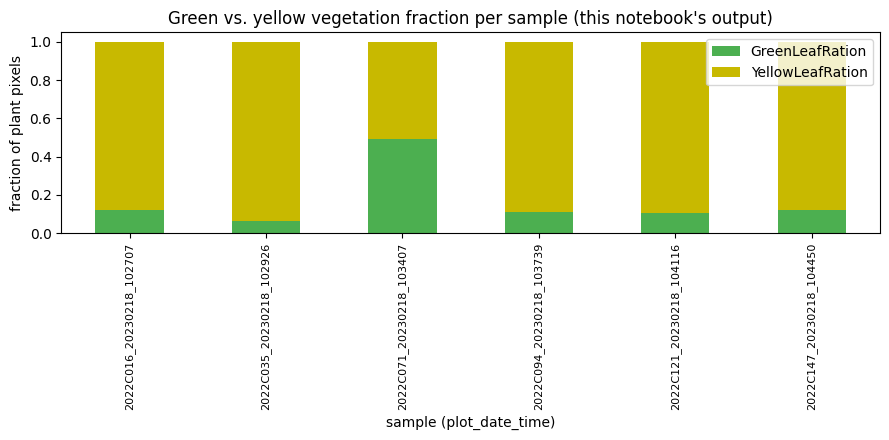

saved /content/freeze_phenotypes.csv


In [ ]:
ax = df.plot.bar(x="Plot", y=["GreenLeafRation", "YellowLeafRation"], stacked=True,
                 figsize=(9, 4.5), color=["#4caf50", "#c8b900"])
ax.set_ylabel("fraction of plant pixels")
ax.set_xlabel("sample (plot_date_time)")
ax.set_title("Green vs. yellow vegetation fraction per sample (this notebook's output)")
ax.legend(loc="upper right")
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

csv_path = "/content/freeze_phenotypes.csv"
df.to_csv(csv_path, index=False)
print("saved", csv_path)

## 10. Interpretation, limitations, references

**What was executed (this run):** the author's ring-ROI preprocessing, FreezeNet inference, and HSV trait extraction were run verbatim on the six author-provided samples, and the resulting table was compared against the author's own embedded reference outputs from `phenotyping.ipynb` (agreement within 2% asserted in the validation cell). A single 6-sample run does **not** reproduce the paper's dataset-level results (99-image test Dice 89.95%, GWAS QTLs, heritabilities); it demonstrates the minimal inference path.

**Limitations:** areas are 512x512 pixel counts as in the author's notebook (physical cm² calibration from the paper's ring diameter is not in the repository); the checkpoint was verified by strict load + reference agreement, and its download route is printed by the checkpoint cell; no license file exists in the author repository.

**References:**
- Paper: Plant Phenomics 2025;7(2):100061 — https://pmc.ncbi.nlm.nih.gov/articles/PMC12710041/
- Code: https://github.com/Jiang-Phenomics-Lab/FreezeNet (commit `25b66f0b9269bc83a5c95daba153b03b78e6b132`; checkpoint blob at `ccb27fecac629ea775a1d28b33821d2d35d088ab`)
- Author reference outputs: `phenotyping.ipynb` embedded execution result at the pinned commit.

**日本語(要約):** 著者提供サンプル6枚について、リング検出→FreezeNet推論→HSV形質抽出を実行し、著者ノートブックの参照出力と照合しました(±2%以内を検証)。面積はピクセル数単位、学習・GWAS等は対象外です。

In [ ]:
print(f"Reproduction of FreezeNet phenotyping finished on {DEVICE}. "
      f"Samples: {len(df)}; reference agreement asserted in the validation cell. "
      f"Notebook provenance: author code @ {COMMIT}, phenotyping.ipynb reference outputs.")

Reproduction of FreezeNet phenotyping finished on cpu. Samples: 6; reference agreement asserted in the validation cell. Notebook provenance: author code @ 25b66f0b9269bc83a5c95daba153b03b78e6b132, phenotyping.ipynb reference outputs.
